In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy import integrate, interpolate

# Modelando el cúmulo más poblado

En este cúmulo se modela el cúmulo más poblado usando los perfiles de King 1962 y tambiénn se trata de simular la distorsión de la línea de la visual de Gaia.

Se importan tablas.

In [2]:
clusters = pd.read_csv('../data/processed/clusters.csv')
members = pd.read_csv('../data/processed/members.csv')

Se escoge el cúmulo más problado.

In [3]:
max_index = clusters['N'].idxmax()
cluster = clusters.iloc[max_index, :]
cluster_name = cluster['Name']
cluster_members = members[members['Name'] == cluster_name]


Se seleccionan las coordenadas $\text{RA}/\text{DEC}$ del punto más denso del cúmulo y la distancia a ese punto. También se seleccionan los radios $r_c$ y $r_t$ dados por el catálogo.

In [4]:
ra0 = cluster['RA_ICRS']
dec0 = cluster['DE_ICRS']
d0 = cluster['dist50']

rc = cluster['rcpc']
rt = cluster['rtpc']

Se seleccionan todas las posiciones $\text{RA}/\text{DEC}$ y distancias de los miembros del cúmulo.

In [5]:
ras = cluster_members['RA_ICRS'].values
decs = cluster_members['DE_ICRS'].values
ds = cluster_members['r_med_photogeo'].values

Se calcula la distancia angular de los miembros del cúmulo al puto más denso.

In [6]:
def angular_distances(ra0, dec0, ras, decs):
    ra0 = np.radians(ra0)
    dec0 = np.radians(dec0)
    ras = np.radians(ras)
    decs = np.radians(decs)

    delta_ra = ras - ra0
    delta_dec = decs - dec0

    a = np.sin(delta_dec / 2)**2 + np.cos(dec0) * np.cos(decs) * np.sin(delta_ra / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    return c

In [7]:
ang_dist = angular_distances(ra0, dec0, ras, decs)

Se calculan las distancias proyectadas $r$ de los miembros a la línea de la visual en $\text{pc}$ con: $$r = d_0 \tan{\theta}$$

In [8]:
rs = d0 * np.tan(ang_dist)

## Perfil de King

Se tiene que la densidad proyectada (densidad superficial) es: $$\Sigma(r) = k\left(\frac{1}{[1+(r/r_c)^2]^\frac{1}{2}} - \frac{1}{[1+(r_t/r_c)^2]^\frac{1}{2}}\right)^2$$ de esta se puede encontrar que la densidad espacial es: $$\rho(r) = \frac{k}{\pi r_c \left[1+(r_t/r_c)^2 \right]^{\frac{3}{2}}} \frac{1}{w^2}\left[\frac{1}{w}\cos^{-1}w - (1-w^2)^\frac{1}{2}\right]$$ donde $$w = \left[\frac{1+(r/r_c)^2}{1+(r_t/r_c)^2}\right]^\frac{1}{2}$$

## Ajuste de la densidad proyectada

Perfil de densidad superficial proyectada:

In [9]:
def sigma(r, rc, rt, k):
    term1 = 1 / (1 + (r / rc)**2)**0.5
    term2 = 1 / (1 + (rt / rc)**2)**0.5

    sigma = k * (term1 - term2)**2
    sigma[r > rt] = 0
    
    return sigma

Se calcula la densidad superficial observada.

In [10]:
num_bins = 30
counts, bin_edges = np.histogram(rs, bins=num_bins)

Se calcula el radio medio de cada anillo.

In [11]:
r_mid = 0.5 * (bin_edges[1:] + bin_edges[:-1])

Se calcula el área de cada anillo.

In [12]:
areas = np.pi * (bin_edges[1:]**2 - bin_edges[:-1]**2)

Se calcula la densidad observada.

In [13]:
sigma_obs = counts / areas

### Ajuste de la curva

Estimaciones iniciales.

In [14]:
k_guess = np.max(sigma_obs)
rc_guess = np.median(rs) * 0.5
rt_guess = np.max(rs)

Ajustando.

In [15]:
p0 = [rc_guess, rt_guess, k_guess]
popt, pcov = curve_fit(sigma, r_mid, sigma_obs, p0=p0, bounds=(0, np.inf))

### Gráfica del ajuste

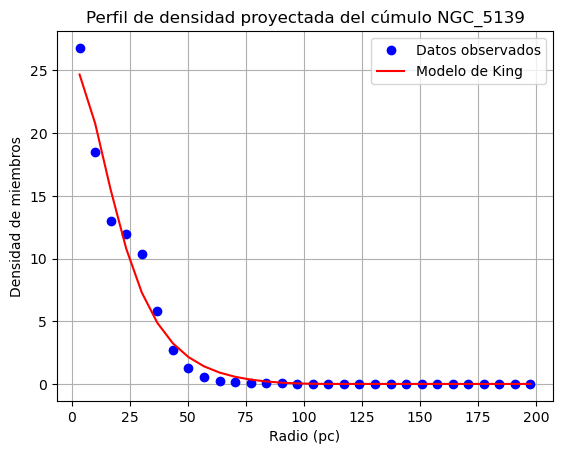

In [16]:
plt.plot(r_mid, sigma_obs, label='Datos observados', marker='o', linestyle='None', color='blue')
plt.plot(r_mid, sigma(r_mid, *popt), label='Modelo de King', color='red')
plt.xlabel('Radio (pc)')
plt.ylabel('Densidad de miembros')
plt.title(f'Perfil de densidad proyectada del cúmulo {cluster_name}')
plt.legend()
plt.grid()
plt.show()

In [17]:
rc_fit, rt_fit, k_fit = popt

print('Parámetros ajustados:')
print(f'rc: {rc_fit:.2f} [pc]')
print(f'rt: {rt_fit:.2f} [pc]')
print(f'k: {k_fit:.2f} [stars/pc^2]')

print('\nParámetros del catálogo:')
print(f'rc: {rc:.2f} [pc]')
print(f'rt: {rt:.2f} [pc]')

Parámetros ajustados:
rc: 25.00 [pc]
rt: 112.37 [pc]
k: 41.21 [stars/pc^2]

Parámetros del catálogo:
rc: 52.73 [pc]
rt: 65.34 [pc]


## Modelando el cúmulo

Perfil de densidad de King.

In [18]:
def rho(r, rc, rt, k):
  values = np.zeros_like(r, dtype=float)

  mask = r < rt
  r_valid = r[mask]

  w = np.sqrt((1 + (r_valid/rc)**2) / (1 + (rt/rc)**2))

  C = k / (np.pi * rc * (1 + (rt/rc)**2)**1.5)

  term1 = 1.0 / (w**2)
  term2 = (1.0 / w) * np.arccos(w) - np.sqrt(1 - w**2)

  values[mask] = C * term1 * term2
  
  return values

Se necesita la masa acumulada $M(r)$, la masa encerrada hasta $r$ es: $$M(r) = \int_0^r 4\pi r'^2\rho(r')\ \mathrm{d}r'$$ luego de esto sale la función de distribución acumulada (CDF) radial: $$P(r) = \frac{M(r)}{M_\text{total}}$$

### Construyedo $M(r)$ numéricamente

Se crea una malla fina de radios

In [19]:
r_min = 0
r_max = rt_fit

r_grid = np.linspace(r_min, r_max, 1000)

Se calculan las densidades en cada radio.

In [20]:
rho_grid = rho(r_grid, rc_fit, rt_fit, k_fit)

Se integra $M(r)$

In [21]:
integrando = 4 * np.pi * r_grid**2 * rho_grid
M_r = integrate.cumulative_trapezoid(integrando, r_grid, initial=0)

Se normaliza para obtener la CDF ($P(r)$)

In [22]:
cdf = M_r / M_r[-1]

Se crea una función inversa de la CDF usando interpolación

In [23]:
inv_cdf = interpolate.interp1d(cdf, r_grid)

### Muestreo de Monte Carlo

Se genera radios $r$

In [24]:
N = cluster['N']

u = np.random.uniform(0, 1, size=N)
r_samples = inv_cdf(u)

Se generan ángulos isotrópicos.

In [25]:
v = np.random.uniform(0, 1, size=N)
w = np.random.uniform(0, 1, size=N)

In [26]:
phi = 2 * np.pi * w
theta = np.arccos(1 - 2 * v)

Se convierte a coordenadas cartesianas

In [27]:
x_samples = r_samples * np.sin(theta) * np.cos(phi)
y_samples = r_samples * np.sin(theta) * np.sin(phi)
z_samples = r_samples * np.cos(theta)

In [28]:
x0_sample = x_samples.mean()
y0_sample = y_samples.mean()
z0_sample = z_samples.mean()

### Gráfica en cartesianas del cúmulo modelado

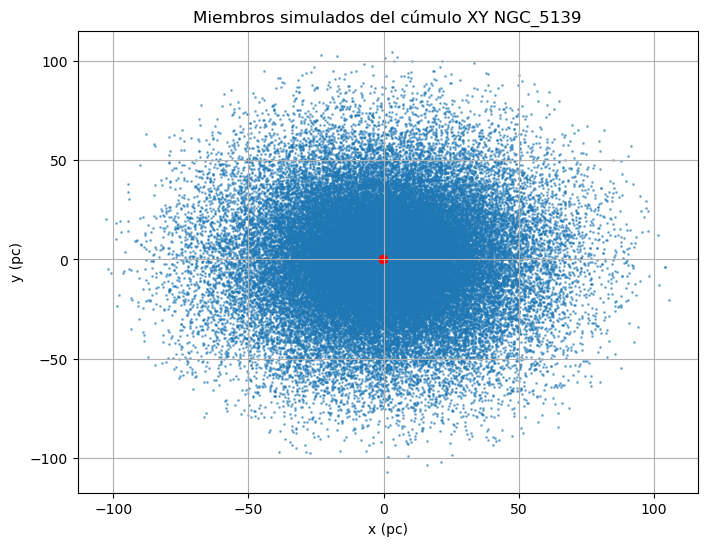

In [29]:
plt.figure(figsize=(8, 6))
plt.scatter(x_samples, y_samples, s=1, alpha=0.5)
plt.scatter(x0_sample, y0_sample, color='red', label='Centroide simulado')
plt.xlabel('x (pc)')
plt.ylabel('y (pc)')
plt.title(f'Miembros simulados del cúmulo XY {cluster_name}')
plt.grid()
plt.show()

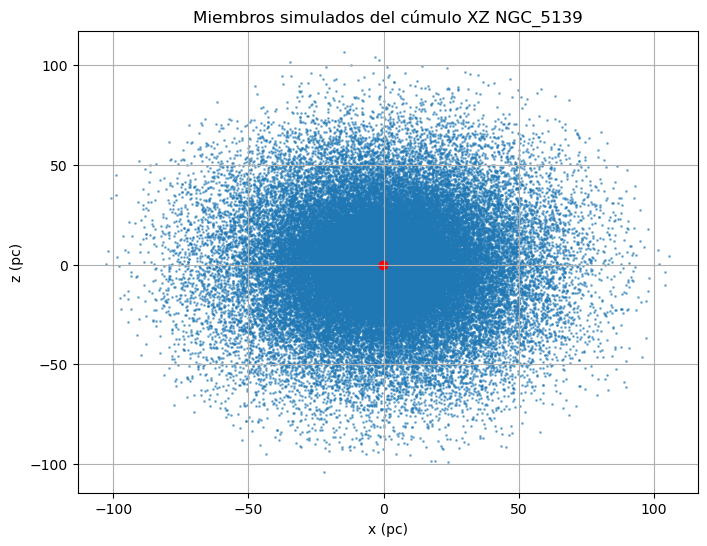

In [30]:
plt.figure(figsize=(8, 6))
plt.scatter(x_samples, z_samples, s=1, alpha=0.5)
plt.scatter(x0_sample, z0_sample, color='red', label='Centroide simulado')
plt.xlabel('x (pc)')
plt.ylabel('z (pc)')
plt.title(f'Miembros simulados del cúmulo XZ {cluster_name}')
plt.grid()
plt.show()

## Simulación de la distorsión

### Mover el cúmulo a su distancia real

El modelo de King está centrado en el origen. Para que el paralaje fucione se debe poner el cúmulo a la distancia real del cúmulo, esto es: $$d_{\text{true}, i} = d_0 + z_{\text{king}, i}$$

### Convertir la distancia a paralaje "verdadero"

Se convierte la distacia a paralaje, lo que Gaia mediría en un universo perfecto: $$\omega_{\text{true}, i} = \frac{1000}{d_{\text{true}, i}}$$


### Muestrear los errores de Gaia

Se toman los errores del paralaje medidos por Gaia de las estrellas miembros y para cada partícula del modelo de King se selecciona aleatoriamente un error de paralaje $\sigma_{\omega, i}$ del conjunto de datos de Gaia. DE esta forma se mantienen la misma relación S/N del conjunto original.

### Innyectar el error para obtener el paralaje "observado"

Se simuala la medicióo de Gaia añadiendo ruido Gaussiano al paralaje verdadero usando los errores extraidos anteriormente, esto es: $$\omega_{\text{obs}, i} = \omega_{\text{true}, i} + N(0, \sigma_{\omega, i})$$ donde $N(0, \sigma)$ es un número aleatorio sacado de una distribuciónnn normal con media $0$ y desviación estandar $\sigma$.

### Transformar de vuelta a distancia (Elongación)

Se convierte el paralaje observado que ahora tiene ruido de vuelta a distancia. Esto se hace con: $$d_{\text{obs}, i} = \frac{1000}{\omega_{\text{obs}, i}}$$

### Centrar de nuevo el cúmulo

Para comparar el modelo con el modelo de King se debe restar la distancia media para que vuelva a estar centrado en $0$: $$z_{\text{distorsionado}, i} = d_{\text{obs}, i} - d_0$$


Se escogen los errores en el paralaje dados por Gaia

In [31]:
e_plxs = cluster_members['e_Plx'].values

In [32]:
def sim_gaia_distortion(zs, e_plx, d0):
    d_true = d0 + zs

    plx_true = 1e3 / d_true

    sigma_plx = np.random.choice(e_plx, size=len(zs))

    plx_obs = np.random.normal(loc=plx_true, scale=sigma_plx)

    mask = plx_obs > 1e-5

    zs_distorted = np.full_like(zs, np.nan)

    d_obs = 1e3 / plx_obs[mask]

    zs_distorted[mask] = d_obs - d0

    return zs_distorted

In [33]:
zs_distorted = sim_gaia_distortion(z_samples, e_plxs, d0)

### Gráficas de la simulación de la distorsión

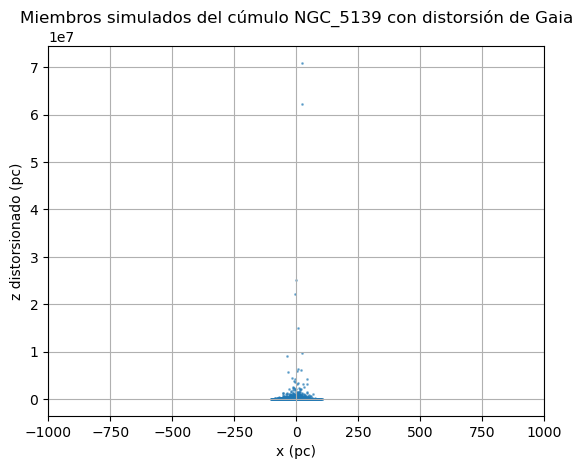

In [34]:
plt.scatter(x_samples, zs_distorted, s=1, alpha=0.5)
plt.xlabel('x (pc)')
plt.ylabel('z distorsionado (pc)')
plt.title(f'Miembros simulados del cúmulo {cluster_name} con distorsión de Gaia')
plt.xlim(-1000, 1000)
plt.grid()
plt.show()